## Generate UMAP embeddings from data after QC and PyOD ECOD, and plot facet UMAP

In [1]:
from pathlib import Path

import pandas as pd
import umap
from plotnine import (
    aes,
    element_text,
    facet_wrap,
    geom_point,
    ggplot,
    guide_legend,
    guides,
    labs,
    scale_color_brewer,
    theme,
    theme_bw,
)
from plotnine.options import set_option
from pycytominer.cyto_utils import infer_cp_features


In [2]:
# Set constants
umap_random_seed = 0
umap_n_components = 2

# Set output directories
figure_dir = Path("./figures")
output_dir = Path("./umap_embeddings")
output_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)


In [3]:
# Load in coSMicQC (post-QC) normalized dataframe for CFReT example plate
cosmicqc_df = pd.read_parquet(
    Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/3.process_cfret_features/data/single_cell_profiles/localhost230405150001_sc_feature_selected.parquet"
    )
)

# Drop any NaN rows from columns that are not metadata (contain Metadata_ prefix)
cosmicqc_df = cosmicqc_df.dropna(
    subset=[col for col in cosmicqc_df.columns if not col.startswith("Metadata_")]
).reset_index(drop=True)

# Blind treatments for UMAP visualization
# (DMSO = control, TGFRi = treatment2, drug_X = treatment3)
treatment_mapping = {
    "DMSO": "control",
    "TGFRi": "treatment1",
    "drug_x": "treatment2",
}
cosmicqc_df["Metadata_treatment"] = cosmicqc_df["Metadata_treatment"].map(
    treatment_mapping
)

# Change cell type "failing" to "diseased" for better interpretability in the figure
cell_type_mapping = {"failing": "diseased"}
cosmicqc_df["Metadata_cell_type"] = cosmicqc_df["Metadata_cell_type"].map(
    lambda x: cell_type_mapping.get(x, x)
)

# Create new column for treatment cell type ID for each unique combo
cosmicqc_df["Metadata_Treatment_CellType_ID"] = (
    cosmicqc_df["Metadata_treatment"] + "_" + cosmicqc_df["Metadata_cell_type"]
)

# Update treatment-cell type IDs for plain English formatting
cosmicqc_df["Metadata_Treatment_CellType_ID"] = cosmicqc_df[
    "Metadata_Treatment_CellType_ID"
].replace(
    {
        "control_diseased": "DMSO-control diseased",
        "treatment1_diseased": "Treatment 1 diseased",
        "treatment2_diseased": "Treatment 2 diseased",
        "control_healthy": "DMSO-control healthy",
        "treatment1_healthy": "Treatment 1 healthy",
        "treatment2_healthy": "Treatment 2 healthy",
    }
)

# Print shape of the DataFrame
print(cosmicqc_df.shape)
cosmicqc_df.head()


(20865, 677)


,Metadata_WellRow,Metadata_WellCol,Metadata_heart_number,Metadata_cell_type,Metadata_heart_failure_type,Metadata_treatment,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,...,Nuclei_Texture_InverseDifferenceMoment_ER_3_03_256,Nuclei_Texture_InverseDifferenceMoment_Mitochondria_3_03_256,Nuclei_Texture_InverseDifferenceMoment_PM_3_01_256,Nuclei_Texture_InverseDifferenceMoment_PM_3_03_256,Nuclei_Texture_SumEntropy_PM_3_01_256,Nuclei_Texture_SumVariance_ER_3_03_256,Nuclei_Texture_SumVariance_Hoechst_3_03_256,Nuclei_Texture_SumVariance_Mitochondria_3_01_256,Nuclei_Texture_SumVariance_PM_3_01_256,Metadata_Treatment_CellType_ID
0,B,2,9,diseased,rejected,control,221.046761,137.115493,246.602800,109.285755,...,-0.393448,0.961214,0.406068,0.374039,-0.280532,-0.158967,-0.344804,-0.263653,-0.305486,DMSO-control diseased
1,B,2,9,diseased,rejected,control,690.596142,183.067828,716.170091,177.132195,...,-0.618520,-0.050925,0.424753,0.323462,-0.096856,-0.218001,-0.359297,2.621455,-0.175679,DMSO-control diseased
2,B,2,9,diseased,rejected,control,626.561490,206.923698,623.943740,199.906440,...,-0.213998,0.492022,0.783465,0.531513,-0.515924,-0.090464,-0.381751,-0.234890,-0.312005,DMSO-control diseased
3,B,2,9,diseased,rejected,control,559.448583,220.688160,528.646623,196.955552,...,0.066951,0.233985,0.697668,0.386800,0.216837,-0.078625,-0.345897,-0.148249,-0.205381,DMSO-control diseased
4,B,2,9,diseased,rejected,control,909.019946,247.694340,897.965996,253.621836,...,0.796587,-0.833035,0.971781,0.969710,-0.859995,-0.437968,-0.375427,0.054053,-0.346036,DMSO-control diseased


In [4]:
# Process cosmicqc_df to separate features and metadata
cp_features = infer_cp_features(cosmicqc_df)
meta_features = infer_cp_features(cosmicqc_df, metadata=True)

# Make sure to reinitialize UMAP instance per plate
umap_fit = umap.UMAP(
    random_state=umap_random_seed, n_components=umap_n_components, n_jobs=1
)

# Fit UMAP and convert to pandas DataFrame
embeddings = pd.DataFrame(
    umap_fit.fit_transform(cosmicqc_df.loc[:, cp_features]),
    columns=[f"UMAP{x}" for x in range(0, umap_n_components)],
)
print(f"{embeddings.shape} UMAP embeddings generated")

# Combine with metadata
cosmicqc_umap_df = pd.concat([cosmicqc_df.loc[:, meta_features], embeddings], axis=1)

# Save UMAP with metadata DataFrame
cosmicqc_umap_df.to_parquet(output_dir / "post_QC_umap_embeddings.parquet")


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.


(20865, 2) UMAP embeddings generated


In [5]:
# Load in PyOD ECOD normalized dataframe for CFReT example plate
ecod_df = pd.read_parquet(
    Path(
        "./data/ecod_retransplant_norm_fs.parquet"
    )
)

# Drop any NaN rows from columns that are not metadata (contain Metadata_ or Image_ prefix)
ecod_df = ecod_df.dropna(
    subset=[
        col for col in ecod_df.columns if not col.startswith(("Metadata_", "Image_"))
    ]
).reset_index(drop=True)

# Blind treatments for UMAP visualization
ecod_df["Metadata_treatment"] = ecod_df["Metadata_treatment"].map(treatment_mapping)

# Change cell type "failing" to "diseased" for better interpretability in the figure
ecod_df["Metadata_cell_type"] = ecod_df["Metadata_cell_type"].map(
    lambda x: cell_type_mapping.get(x, x)
)

# Create new column for treatment cell type ID for each unique combo
ecod_df["Metadata_Treatment_CellType_ID"] = (
    ecod_df["Metadata_treatment"] + "_" + ecod_df["Metadata_cell_type"]
)

# Update treatment-cell type IDs for plain English formatting
ecod_df["Metadata_Treatment_CellType_ID"] = ecod_df[
    "Metadata_Treatment_CellType_ID"
].replace(
    {
        "control_diseased": "DMSO-control diseased",
        "treatment1_diseased": "Treatment 1 diseased",
        "treatment2_diseased": "Treatment 2 diseased",
        "control_healthy": "DMSO-control healthy",
        "treatment1_healthy": "Treatment 1 healthy",
        "treatment2_healthy": "Treatment 2 healthy",
    }
)

# Print shape of the DataFrame
print(ecod_df.shape)
ecod_df.head()


(20868, 738)


,Metadata_WellRow,Metadata_WellCol,Metadata_heart_number,Metadata_cell_type,Metadata_heart_failure_type,Metadata_treatment,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,...,Nuclei_Texture_InverseDifferenceMoment_PM_3_01_256,Nuclei_Texture_InverseDifferenceMoment_PM_3_02_256,Nuclei_Texture_InverseDifferenceMoment_PM_3_03_256,Nuclei_Texture_SumEntropy_ER_3_01_256,Nuclei_Texture_SumEntropy_Mitochondria_3_01_256,Nuclei_Texture_SumVariance_ER_3_01_256,Nuclei_Texture_SumVariance_Hoechst_3_03_256,Nuclei_Texture_SumVariance_Mitochondria_3_01_256,Nuclei_Texture_SumVariance_PM_3_01_256,Metadata_Treatment_CellType_ID
0,B,2,9,diseased,rejected,control,221.046761,137.115493,246.602800,109.285755,...,0.398769,0.301243,0.359054,0.642610,-1.202582,-0.072519,-0.377033,-0.316582,-0.405141,DMSO-control diseased
1,B,2,9,diseased,rejected,control,690.596142,183.067828,716.170091,177.132195,...,0.420348,0.608450,0.300448,0.418649,0.900424,-0.200186,-0.400839,5.393910,-0.111241,DMSO-control diseased
2,B,2,9,diseased,rejected,control,626.561490,206.923698,623.943740,199.906440,...,0.834606,0.804181,0.541524,0.740470,-0.335710,-0.053123,-0.437724,-0.259651,-0.419901,DMSO-control diseased
3,B,2,9,diseased,rejected,control,559.448583,220.688160,528.646623,196.955552,...,0.735523,0.810849,0.373841,0.568383,0.440527,-0.119791,-0.378829,-0.088163,-0.178490,DMSO-control diseased
4,B,2,9,diseased,rejected,control,909.019946,247.694340,897.965996,253.621836,...,1.052083,1.391363,1.049276,-0.948459,0.884723,-0.536981,-0.427336,0.312254,-0.496951,DMSO-control diseased


In [6]:
# Process ecod_df to separate features and metadata
ecod_cp_features = infer_cp_features(ecod_df)
ecod_meta_features = infer_cp_features(ecod_df, metadata=True)

# Make sure to reinitialize UMAP instance per plate
ecod_umap_fit = umap.UMAP(
    random_state=umap_random_seed, n_components=umap_n_components, n_jobs=1
)

# Fit UMAP and convert to pandas DataFrame
ecod_embeddings = pd.DataFrame(
    ecod_umap_fit.fit_transform(ecod_df.loc[:, ecod_cp_features]),
    columns=[f"UMAP{x}" for x in range(0, umap_n_components)],
)
print(f"{ecod_embeddings.shape} UMAP embeddings generated")

# Combine with metadata
ecod_umap_df = pd.concat([ecod_df.loc[:, ecod_meta_features], ecod_embeddings], axis=1)

# Save UMAP with metadata DataFrame
ecod_umap_df.to_parquet(output_dir / "post_ECOD_umap_embeddings.parquet")


(20868, 2) UMAP embeddings generated


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 18 x 8 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/facet_umap_coSMicQC_PyOD_ECOD_plot.png


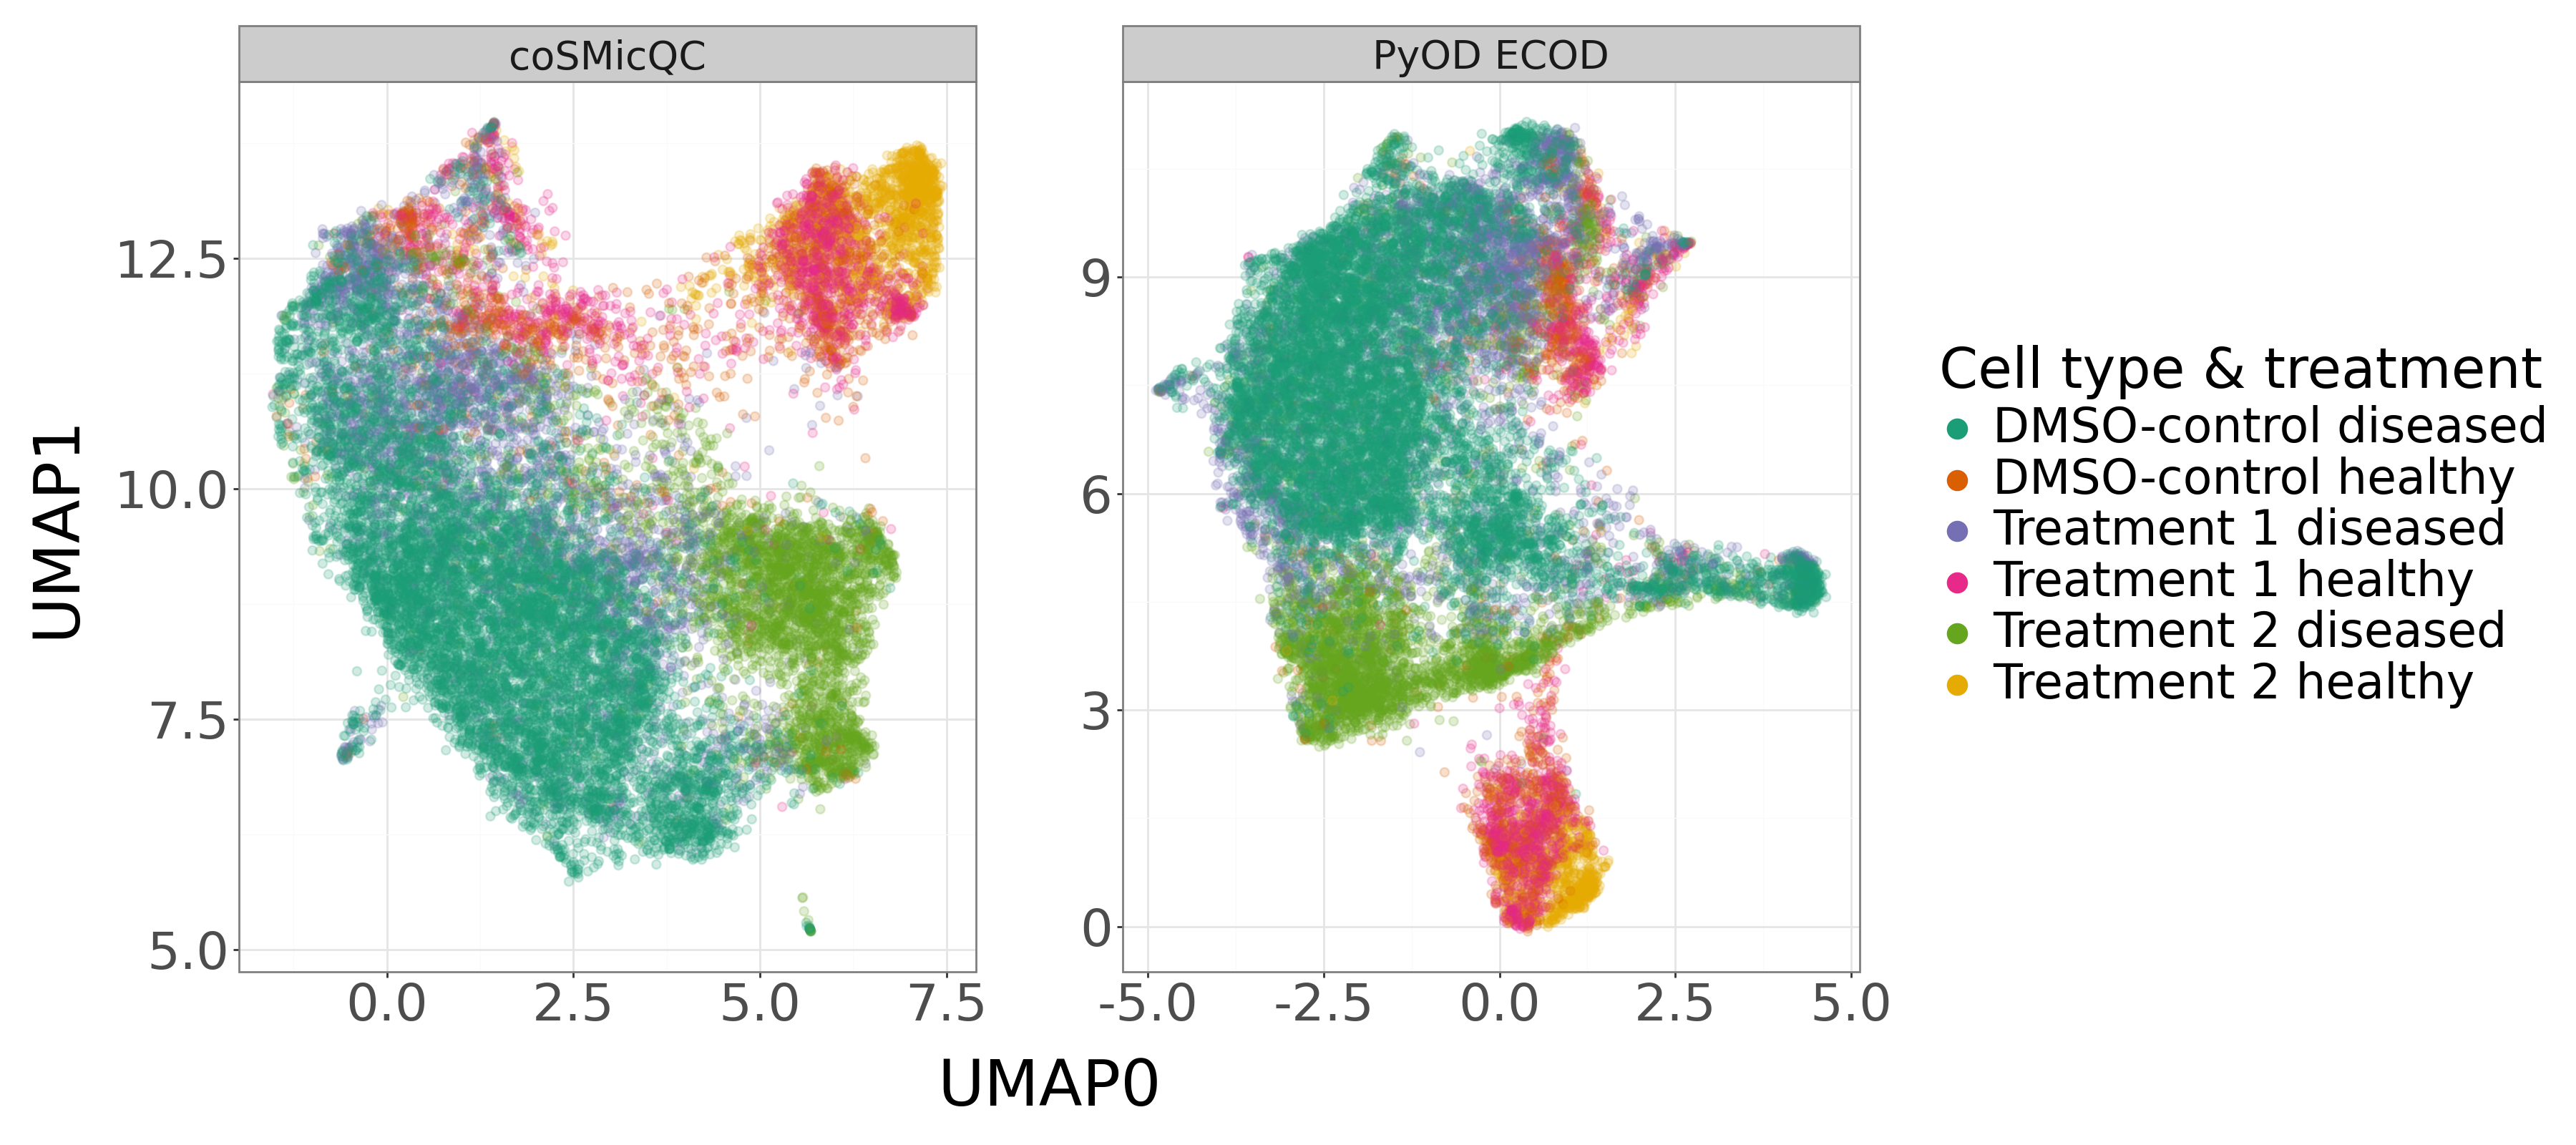

In [7]:
# Tag each dataframe with its QC method
cosmicqc_umap_df = cosmicqc_umap_df.copy()
cosmicqc_umap_df["Metadata_QC_method"] = "coSMicQC"

ecod_umap_df = ecod_umap_df.copy()
ecod_umap_df["Metadata_QC_method"] = "PyOD ECOD"

# Combine both into one dataframe for faceting
combined_umap_df = pd.concat(
    [cosmicqc_umap_df, ecod_umap_df],
    axis=0,
    ignore_index=True,
)

# Force facet order: coSMicQC first, then PyOD ECOD
combined_umap_df["Metadata_QC_method"] = pd.Categorical(
    combined_umap_df["Metadata_QC_method"],
    categories=["coSMicQC", "PyOD ECOD"],
    ordered=True,
)

# Set the figure size (widened slightly to accommodate the right-side legend)
height = 8
width = 18
set_option("figure_size", (width, height))

# Plot with custom color palette, faceted by QC method
p = (
    ggplot(
        combined_umap_df,
        aes(x="UMAP0", y="UMAP1", color="Metadata_Treatment_CellType_ID"),
    )
    + labs(
        color="Cell type & treatment",
    )
    + geom_point(alpha=0.2, size=2)
    + facet_wrap("~Metadata_QC_method", scales="free")
    + theme_bw()
    + theme(
        axis_title=element_text(size=32),
        axis_text=element_text(size=26),
        legend_title=element_text(size=28),
        legend_text=element_text(size=24),
        legend_position="right",
        strip_text=element_text(size=20),  # Adjust facet label size
    )
    + scale_color_brewer(type="qual", palette="Dark2")
    + guides(
        color=guide_legend(
            override_aes={
                "alpha": 1,
                "size": 5,
            },
            ncol=1,  # single column, since legend is now on the right
        )
    )
)

# Save the plot
p.save(
    figure_dir / "facet_umap_coSMicQC_PyOD_ECOD_plot.png",
    dpi=200,
    width=width,
    height=height,
)

p.show()
